In [1]:
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=False)

In [2]:
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name="bastidas-ponce_4K_pancreas-d15_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)

Downloading bucket files: 52931410 / 52931410 complete

Downloading bytes: 52931410 / 52931410 complete

In [3]:
ds = scarf.DataStore(f"{dataset}/data.zarr", nthreads=4)
analysis_run = ds.pipeline.open(label="docs_default")

ds

DataStore has 3696 (3696) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'G2M_score', 'RNA_UMAP1', 
            'RNA_UMAP2', 'RNA_clusters', 'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 
            'RNA_percentMito', 'RNA_percentRibo', 'S_score', 'clusters', 'clusters_coarse'
   RNA assay has 27998 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'highly_variable_genes', 
            'nCells'

In [4]:
cluster_values = analysis_run.cells.fetch("clusters")
cluster_counts = pd.Series(cluster_values, name="cluster").value_counts()
cluster_counts.sort_index().to_frame("cells")

,cells
cluster,
1,367
2,512
3,461
4,236
5,349
6,199
7,145
8,222
9,377


In [5]:
ds.cells.head()[["ids", "I", "clusters"]]

,ids,I,clusters
0,AAACCTGAGAGGGATA,True,Pre-endocrine
1,AAACCTGAGCCTTGAT,True,Ductal
2,AAACCTGAGGCAATTA,True,Alpha
3,AAACCTGCATCATCCC,True,Ductal
4,AAACCTGGTAAGTGGC,True,Ngn3 high EP


In [6]:
ds.RNA.feats.head()

,I,ids,names,dropOuts,highly_variable_genes,nCells
0,True,Xkr4,Xkr4,3690,False,6
1,True,Gm37381,Gm37381,3696,NaN,0
2,True,Rp1,Rp1,3696,NaN,0
3,True,Rp1-1,Rp1-1,3696,NaN,0
4,True,Sox17,Sox17,3696,NaN,0


In [7]:
cell_qc = ds.cells.to_pandas_dataframe(
    columns=["ids", "RNA_nCounts", "RNA_nFeatures", "clusters"]
)
cell_qc.set_index("ids").head()

,RNA_nCounts,RNA_nFeatures,clusters
ids,,,
AAACCTGAGAGGGATA,4954.0,2356.0,Pre-endocrine
AAACCTGAGCCTTGAT,7071.0,2613.0,Ductal
AAACCTGAGGCAATTA,4070.0,1984.0,Alpha
AAACCTGCATCATCCC,8362.0,2860.0,Ductal
AAACCTGGTAAGTGGC,5026.0,2211.0,Ngn3 high EP


In [8]:
first_run_cluster = cluster_values[0]
is_first_cluster = cluster_values == first_run_cluster
ds.cells.insert(
    column_name="is_first_cluster", values=is_first_cluster, overwrite=True
)
pd.Series(is_first_cluster).value_counts().rename("cells")

False    3329
True      367
Name: cells, dtype: int64

In [9]:
ds.cells.to_pandas_dataframe(
    columns=["ids", "clusters", "is_first_cluster"]
).head()

,ids,clusters,is_first_cluster
0,AAACCTGAGAGGGATA,Pre-endocrine,True
1,AAACCTGAGCCTTGAT,Ductal,False
2,AAACCTGAGGCAATTA,Alpha,False
3,AAACCTGCATCATCCC,Ductal,False
4,AAACCTGGTAAGTGGC,Ngn3 high EP,False


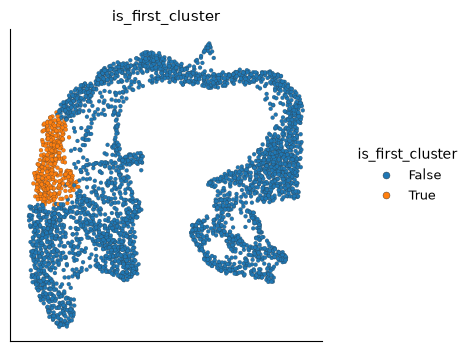

In [10]:
ds.plots.embedding(layout=analysis_run["umap"], color_by="is_first_cluster")

In [11]:
print(
    "fetch:",
    ds.cells.fetch("clusters", key="is_first_cluster").shape,
    "fetch_all:",
    ds.cells.fetch_all("clusters").shape,
)

fetch: (367,) fetch_all: (3696,)


In [12]:
active_before = int(ds.cells.fetch_all("I").sum())
count_range = ds.cells.sift("RNA_nCounts", min_v=1000, max_v=15000)
{"cells in count range": int(count_range.sum())}

{'cells in count range': 3669}

In [13]:
joint_range = ds.cells.multi_sift(
    columns=["RNA_nCounts", "RNA_nFeatures"],
    lows=[1000, 500],
    highs=[15000, 4000],
)
{"cells in both QC ranges": int(joint_range.sum())}

{'cells in both QC ranges': 3667}

In [14]:
ductal_rows = ds.cells.get_index_by(["Ductal"], "clusters")

print("Ductal cells:", int(ductal_rows.size))
print("Active cells (I) before:", active_before)
print("Active cells (I) after:", int(ds.cells.fetch_all("I").sum()))

Ductal cells: 916
Active cells (I) before: 3696
Active cells (I) after: 3696


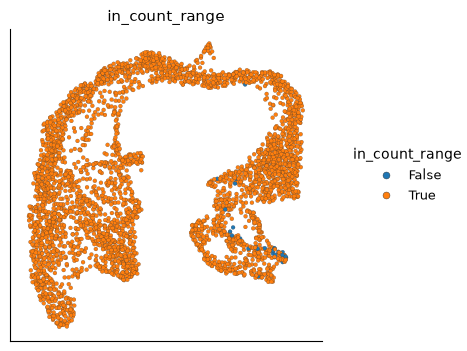

In [15]:
ds.cells.insert(column_name="in_count_range", values=count_range, overwrite=True)
ds.plots.embedding(layout=analysis_run["umap"], color_by="in_count_range")

In [16]:
print("Raw shape:", ds.RNA.rawData.shape)
print("Normed shape:", ds.RNA.normed().shape)

Raw shape: (3696, 27998)
Normed shape: (3696, 27998)


In [17]:
reused_normalized = ds.run_normalization(
    analysis_run["analysis_cell_selection"],
    analysis_run["highly_variable_features"],
)
print("Reused:", reused_normalized == analysis_run["normalized"])
reused_normalized

Reused: True


ArtifactRef(assay='RNA', kind='normalized', artifact_id='1cfeda57c593...')

In [18]:
status = ds.inspect_artifact(reused_normalized)
print("Complete:", status.complete)
print("Operation:", status.operation)
print("Method:", status.parameters["normalization_method"]["qualname"])
normalization_settings = {
    key: status.parameters[key]
    for key in ("size_factor", "log_transform", "renormalize_subset")
}

group = ds.load_artifact(reused_normalized)
print("Arrays:", list(group.array_keys())[:5])
pd.Series(normalization_settings, name="value").rename_axis("setting").to_frame()

Complete: True
Operation: run_normalization
Method: norm_lib_size
Arrays: ['feature_sum', 'data', 'feature_squared_sum']


,value
setting,
size_factor,1000.0
log_transform,True
renormalize_subset,True


In [19]:
ds.show_zarr_tree(depth=0)

/
├── RNA
├── artifacts
├── cellData
└── pipeline



In [20]:
metadata_arrays = {
    name: ds.zw["cellData"][name]
    for name in ("I", "RNA_nCounts", "RNA_nFeatures")
}
pd.DataFrame({
    name: {
        "shape": array.shape,
        "dtype": str(array.dtype),
        "chunks": array.chunks,
    }
    for name, array in metadata_arrays.items()
}).T.rename_axis("cellData column")

,shape,dtype,chunks
cellData column,,,
I,"(3696,)",bool,"(100000,)"
RNA_nCounts,"(3696,)",float64,"(100000,)"
RNA_nFeatures,"(3696,)",float64,"(100000,)"


In [21]:
ds.cells.to_pandas_dataframe(["I"])["I"].value_counts()

I
True    3696
Name: count, dtype: int64

In [22]:
ds.show_zarr_tree(start="RNA", depth=1)

/RNA
├── artifacts
│   ├── ann_index
│   ├── cluster_labels
│   ├── cluster_selection
│   ├── connectivity_map
│   ├── embedding
│   ├── embedding_initialization
│   ├── feature_scaling
│   ├── feature_selection
│   ├── feature_summary
│   ├── marker_table
│   ├── metadata_snapshot
│   ├── neighbors
│   ├── normalized
│   └── reduction
├── countSummaries
│   ├── columnPositive (27998,) int64
│   ├── featureSums
│   ├── rowPositive (3696,) int64
│   └── rowSums (3696,) float64
├── counts (3696, 27998) uint16
├── countsT (27998, 3696) uint16
└── featureData
    ├── I (27998,) bool
    ├── __scarf_missing__highly_variable_genes (27998,) bool
    ├── dropOuts (27998,) int64
    ├── highly_variable_genes (27998,) <U5
    ├── ids (27998,) <U15
    ├── nCells (27998,) int64
    └── names (27998,) <U15

  counts: shape=(3696, 27998), dtype=uint16, chunks=(3696, 13528), shards=(3696, 40584)
  countsT: shape=(27998, 3696), dtype=uint16, chunks=(27056, 1848), shards=(27056, 3696)
